# FER-2013: CNN Baseline (No Stabilisation)
This notebook trains a simple CNN baseline on the same shared FER-2013 split used by the ANN.

## 1. Imports and Configuration
This section imports libraries, sets seeds, and loads the shared train/val/test arrays.

In [1]:
# --- Standard library imports ---
import os
import pathlib
import random

# --- Third-party imports ---
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Shared split file created by the ANN notebook.
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# Training hyperparameters (match ANN for fairness).
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

if not SPLITS_PATH.exists():
    raise FileNotFoundError(
        f"Split file not found: {SPLITS_PATH.resolve()}\n"
        "Run the ANN notebook first to create fer-2013_splits.npz."
    )

print("Using SPLITS_PATH:", SPLITS_PATH.resolve())


Using SPLITS_PATH: C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\fer-2013_splits.npz


## 2. Load Shared Splits
This section loads the saved arrays so the CNN is trained and tested on the exact same data as the ANN.

In [2]:
# Load shared splits saved in fer-2013_splits.npz
splits = np.load(SPLITS_PATH, allow_pickle=True)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]
class_names      = splits["class_names"].tolist()
num_classes      = len(class_names)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", class_names)


Train: (22967, 48, 48, 1) Val: (5742, 48, 48, 1) Test: (7178, 48, 48, 1)
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Compute Class Weights (Baseline)
This section computes balanced class weights from the training set (no capping).

In [3]:
# Compute class weights from TRAIN labels only.
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0265957446808511), 1: np.float64(9.401146131805158), 2: np.float64(1.0012206286237413), 3: np.float64(0.5684338184338185), 4: np.float64(0.8260322255790534), 5: np.float64(0.849120082815735), 6: np.float64(1.2932597556168703)}


## 4. Build and Compile Baseline CNN
This section defines a simple CNN without BatchNorm, weight capping, or other stabilisation improvements.

In [4]:
# --- Baseline CNN ---
# This model is intentionally simple:
# - Light augmentation
# - 3 conv blocks (Conv -> ReLU -> MaxPool)
# - Flatten -> Dense -> Dropout -> Softmax
# It does NOT include BatchNorm or GlobalAveragePooling (those are stabilisation/capacity changes).
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
], name="augment")

def build_cnn(num_classes):
    inputs = tf.keras.layers.Input(shape=(48, 48, 1), name="input")
    x = data_augment(inputs)

    # Conv block 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Conv block 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Conv block 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classifier head
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)
    return tf.keras.Model(inputs, outputs, name="CNN_Baseline")

cnn = build_cnn(num_classes)

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train CNN (Baseline)
This section trains the baseline CNN using early stopping and raw class weights.

In [5]:
# Early stopping to avoid overfitting and to keep training comparable to ANN.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.1565 - loss: 1.9311 - val_accuracy: 0.2555 - val_loss: 1.8228
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.2459 - loss: 1.8401 - val_accuracy: 0.2727 - val_loss: 1.7716
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.2794 - loss: 1.7789 - val_accuracy: 0.3366 - val_loss: 1.6912
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.3138 - loss: 1.7297 - val_accuracy: 0.3636 - val_loss: 1.6423
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3350 - loss: 1.6801 - val_accuracy: 0.3983 - val_loss: 1.5614
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.3587 - loss: 1.6415 - val_accuracy: 0.4060 - val_loss: 1.5627
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3759 - loss: 1.6004 - val_accuracy: 0.4296 - val_loss: 1.5006
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 46s 79ms/step - accuracy: 0.3933 - loss: 1.5491 - 

## 6. Plot & Save Training Curves
This cell generates the learning curves and saves them as PDFs

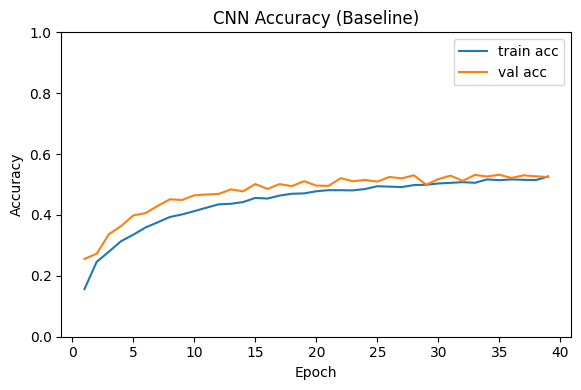

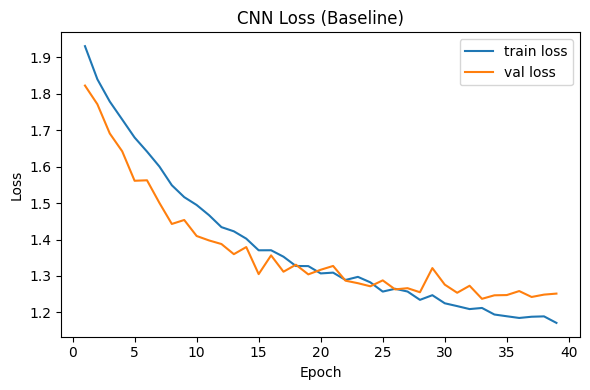

Saved PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\cnn\cnn_baseline_accuracy.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\cnn\cnn_baseline_loss.pdf


In [6]:
import pathlib
import matplotlib.pyplot as plt

OUT_DIR = pathlib.Path("results/plots/cnn/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "CNN"
FILE_PREFIX = "cnn_baseline"

# Work out how many epochs actually ran (EarlyStopping may stop early)
epochs_ran = range(1, len(history.history.get("loss", [])) + 1)

# -------- Accuracy plot --------
plt.figure(figsize=(6, 4))

train_acc = history.history.get("accuracy", None)
val_acc = history.history.get("val_accuracy", None)

if train_acc is not None:
    plt.plot(epochs_ran, train_acc, label="train acc")
if val_acc is not None:
    plt.plot(epochs_ran, val_acc, label="val acc")

plt.title(f"{TITLE_PREFIX} Accuracy (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)

acc_pdf_path = OUT_DIR / f"{FILE_PREFIX}_accuracy.pdf"
plt.savefig(acc_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

# -------- Loss plot --------
plt.figure(figsize=(6, 4))

train_loss = history.history.get("loss", None)
val_loss = history.history.get("val_loss", None)

if train_loss is not None:
    plt.plot(epochs_ran, train_loss, label="train loss")
if val_loss is not None:
    plt.plot(epochs_ran, val_loss, label="val loss")

plt.title(f"{TITLE_PREFIX} Loss (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_pdf_path = OUT_DIR / f"{FILE_PREFIX}_loss.pdf"
plt.savefig(loss_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs to:")
print(" -", acc_pdf_path.resolve())
print(" -", loss_pdf_path.resolve())

## 10. Evaluate Baseline CNN & Show Confusion Matrices
This section reports test performance and produces two confusion matrices for later comparison.

CNN Test Accuracy: 0.5276

Classification Report (CNN Baseline):
              precision    recall  f1-score   support

       angry       0.45      0.46      0.45       958
     disgust       0.31      0.50      0.38       111
        fear       0.35      0.23      0.28      1024
       happy       0.76      0.73      0.75      1774
     neutral       0.43      0.60      0.50      1233
         sad       0.43      0.33      0.38      1247
    surprise       0.64      0.72      0.68       831

    accuracy                           0.53      7178
   macro avg       0.48      0.51      0.49      7178
weighted avg       0.52      0.53      0.52      7178



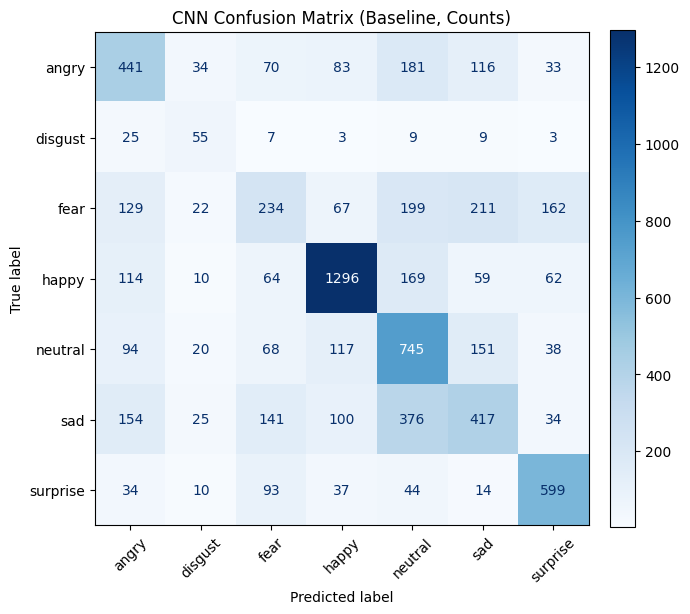

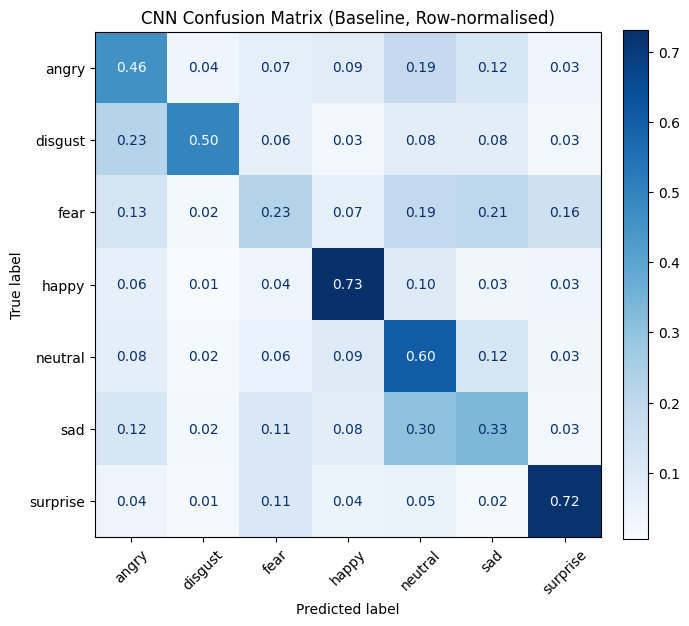


Saved confusion matrix PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\cnn\cnn_baseline_cm_counts.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\cnn\cnn_baseline_cm_row_normalised.pdf


In [7]:
# --- Evaluate CNN + Confusion Matrices (Counts + Row-normalised) + Save as PDFs ---
# This cell:
# 1) Evaluates on the held-out test set
# 2) Generates predictions + classification report
# 3) Plots confusion matrix (counts)
# 4) Plots confusion matrix (row-normalised)
# 5) Saves both confusion matrices as PDFs

import pathlib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1) Evaluate on held-out test set
# -----------------------------
# The test set is never used during training/validation.
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 2) Predict labels (argmax over softmax probabilities)
# -----------------------------
y_pred = np.argmax(cnn.predict(X_test, verbose=0), axis=1)

# -----------------------------
# 3) Classification report (precision/recall/F1)
# -----------------------------
print("\nClassification Report (CNN Baseline):")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# -----------------------------
# 4) Prepare output folder and filenames
# -----------------------------
OUT_DIR = pathlib.Path("results/confusion-matrices/cnn/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "CNN"
FILE_PREFIX = "cnn_baseline"

# -----------------------------
# 5) Confusion Matrix (Counts)
# -----------------------------
cm_counts = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot the matrix WITHOUT a colourbar (we'll add our own so it matches height)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_counts, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)

# Manually add a colourbar that is tied to the matrix axis (same height)
im = ax.images[0]  # the heatmap image
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Baseline, Counts)")
fig.tight_layout()

counts_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_counts.pdf"
fig.savefig(counts_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# -----------------------------
# 6) Confusion Matrix (Row-normalised)
# -----------------------------
# Each row sums to 1.00, so you can compare per-class behaviour fairly.
cm_row = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 7))

# Plot WITHOUT colourbar first
disp = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)

# Add matching-height colourbar
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Baseline, Row-normalised)")
fig.tight_layout()

row_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_row_normalised.pdf"
fig.savefig(row_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# -----------------------------
# 7) Confirm saved files
# -----------------------------
print("\nSaved confusion matrix PDFs to:")
print(" -", counts_pdf_path.resolve())
print(" -", row_pdf_path.resolve())
